<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [94]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install numpy
!pip install scipy

### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [95]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [96]:
## Write your code here
print('COLUMNS : \n', df.columns)

print('TYPES : \n', df.dtypes)

print('SUMMARY INFO : \n', df.info)

COLUMNS : 
 Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='str', length=114)
TYPES : 
 ResponseId               int64
MainBranch                 str
Age                        str
Employment                 str
RemoteWork                 str
                        ...   
JobSatPoints_11        float64
SurveyLength               str
SurveyEase                 str
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object
SUMMARY INFO : 
 <bound method DataFrame.info of        ResponseId                      MainBranch                 Age  \
0               1  I am a developer by profession  Under 18 years old   
1               2  I am a dev

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [97]:
## Write your code here
df.isnull().sum()

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64

### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.

- "Исследуйте ключевые столбцы, такие как Employment (Занятость), JobSat (Удовлетворенность работой) и YearsCodePro    (Профессиональный опыт программирования).

- **Инструкция**: Рассчитайте количество значений для каждого столбца, чтобы понять распределение ответов."

In [98]:
df['JobSat']=df['JobSat'].fillna(df['JobSat'].mode()[0])
df['YearsCodePro']=df['YearsCodePro'].fillna(0)
df['YearsCodePro']=df['YearsCodePro'].replace('Less than 1 year', '0.6')
df['YearsCodePro']=df['YearsCodePro'].replace('More than 50 years', '55')

df['YearsCodePro']=df['YearsCodePro'].astype(float)

In [99]:
print(df['Employment'].value_counts(), '\n')
print(df['JobSat'].value_counts(), '\n')
print(df['YearsCodePro'].value_counts(), '\n')

Employment
Employed, full-time                                                                                                                                   39041
Independent contractor, freelancer, or self-employed                                                                                                   4846
Student, full-time                                                                                                                                     4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                                                                                                     2341
                                                                                                                                                      ...  
Not employed, but looking for work;Independent contra

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


Text(0.5, 1.0, 'Distribution of Job Satisfaction')

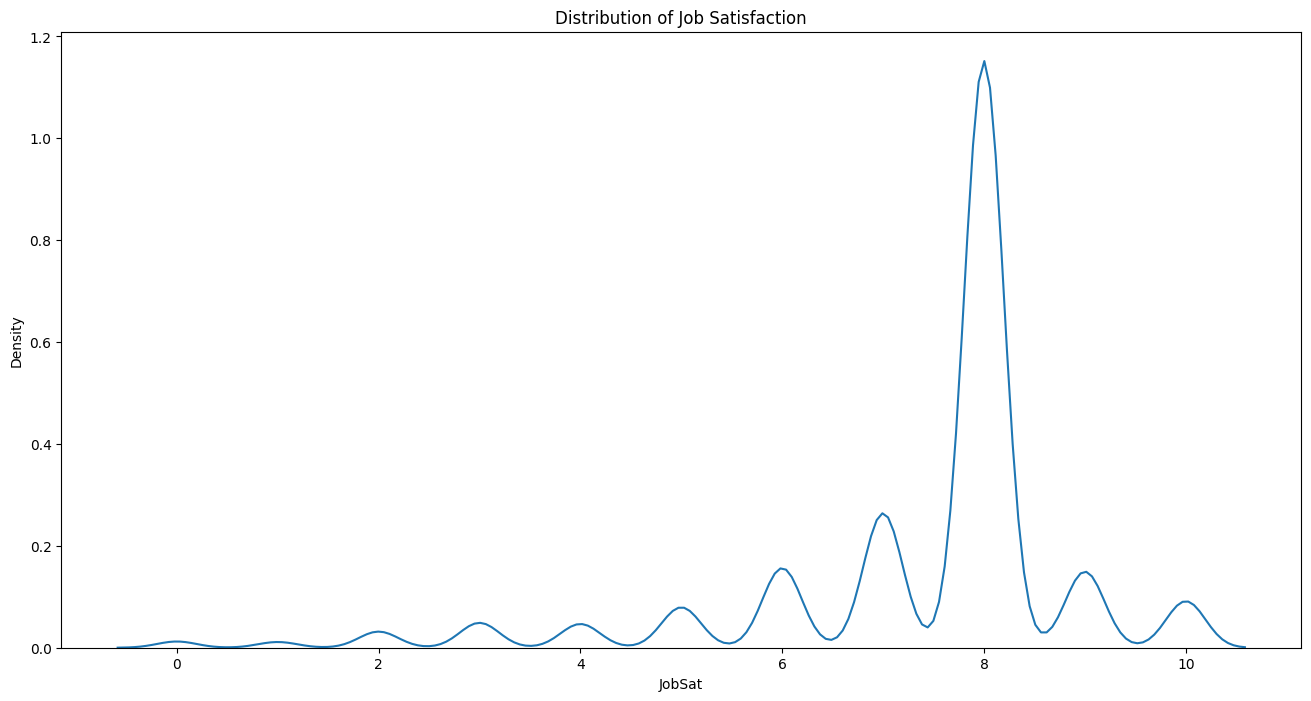

In [132]:
plt.figure(figsize=(16,8))
sns.kdeplot(df, x='JobSat')
plt.title('Distribution of Job Satisfaction')

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.

 - Сравните частоту языков программирования в LanguageHaveWorkedWith и LanguageWantToWorkWith.

 - Визуализируйте пересечение или различия с помощью диаграммы Венна или сгруппированной столбчатой диаграммы.

In [101]:
## Write your code here
df.dropna(subset='LanguageHaveWorkedWith', inplace = True)

In [102]:
df['LanguageWantToWorkWith'].isnull().value_counts()
df.dropna(subset = 'LanguageWantToWorkWith', inplace=True)

In [103]:
dum1 = df['LanguageHaveWorkedWith'].str.get_dummies(sep=(';')).sum().to_frame(name='LanguageHaveWorkedWith')
dum2 = df['LanguageWantToWorkWith'].str.get_dummies(sep=(';')).sum().to_frame(name='LanguageWantToWorkWith')

In [104]:
dum = dum1.join(dum2)
dum = dum.reset_index().melt(id_vars='index',
        value_vars=['LanguageHaveWorkedWith', 'LanguageWantToWorkWith'],
        var_name='Type',
        value_name='Count')
dum.head()

,index,Type,Count
0,Ada,LanguageHaveWorkedWith,457
1,Apex,LanguageHaveWorkedWith,448
2,Assembly,LanguageHaveWorkedWith,3054
3,Bash/Shell (all shells),LanguageHaveWorkedWith,19390
4,C,LanguageHaveWorkedWith,11455


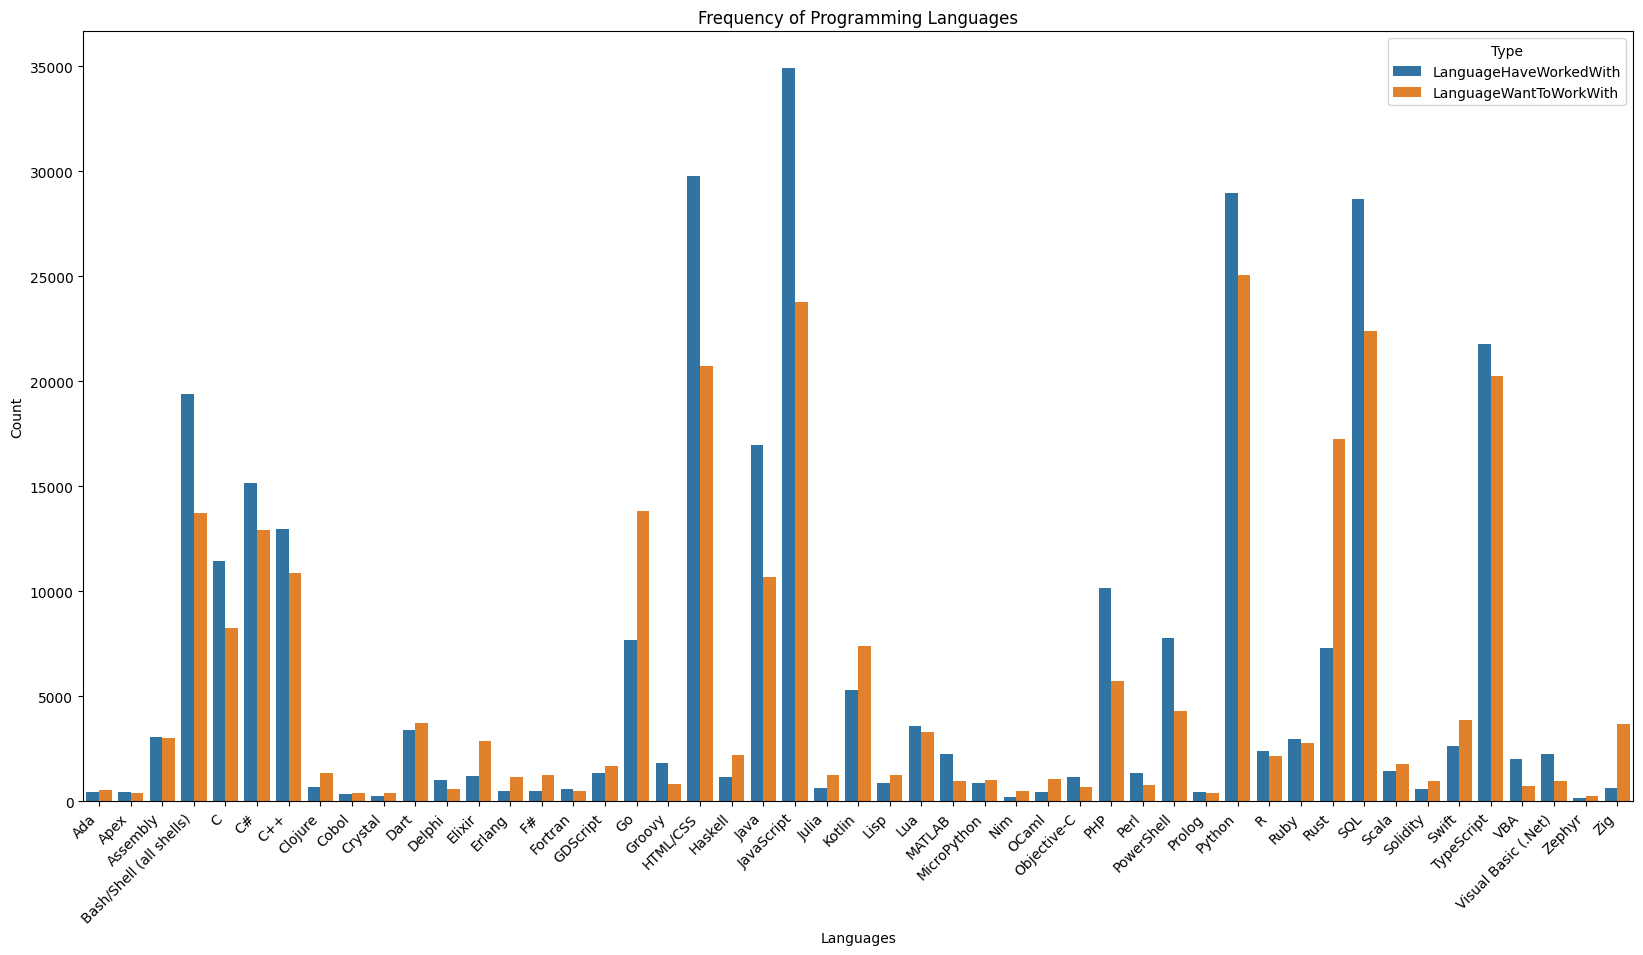

In [105]:
plt.figure(figsize=(20,10))
sns.barplot(data=dum, x= 'index', y='Count', hue='Type')
plt.title('Frequency of Programming Languages')
plt.xlabel('Languages')
plt.xticks(rotation=45, ha='right');

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


In [106]:
countries = [
    "Afghanistan", "Albania", "Algeria", "Andorra", "Angola",
    "Antigua and Barbuda", "Argentina", "Armenia", "Australia", "Austria", "Azerbaijan",
    "Bahamas", "Bahrain", "Bangladesh", "Barbados", "Belarus", "Belgium", "Belize",
    "Benin", "Bhutan", "Bolivia", "Bosnia and Herzegovina", "Botswana", "Brazil",
    "Brunei", "Bulgaria", "Burkina Faso", "Burundi",
    "Cabo Verde", "Cambodia", "Cameroon", "Canada", "Central African Republic", "Chad",
    "Chile", "China", "Colombia", "Comoros", "Congo", "Costa Rica",
    "Côte d'Ivoire", "Croatia", "Cuba", "Cyprus", "Czech Republic",
    "Denmark", "Djibouti", "Dominica", "Dominican Republic",
    "Ecuador", "Egypt", "El Salvador", "Equatorial Guinea", "Eritrea", "Estonia",
    "Eswatini", "Ethiopia",
    "Fiji", "Finland", "France",
    "Gabon", "Gambia", "Georgia", "Germany", "Ghana", "Greece", "Grenada",
    "Guatemala", "Guinea", "Guinea-Bissau", "Guyana",
    "Haiti", "Honduras", "Hungary",
    "Iceland", "India", "Indonesia", "Iran", "Iraq", "Ireland", "Israel", "Italy",
    "Jamaica", "Japan", "Jordan",
    "Kazakhstan", "Kenya", "Kiribati", "Kuwait", "Kyrgyzstan",
    "Laos", "Latvia", "Lebanon", "Lesotho", "Liberia", "Libya", "Liechtenstein",
    "Lithuania", "Luxembourg",
    "Madagascar", "Malawi", "Malaysia", "Maldives", "Mali", "Malta",
    "Marshall Islands", "Mauritania", "Mauritius", "Mexico", "Micronesia",
    "Moldova", "Monaco", "Mongolia", "Montenegro", "Morocco", "Mozambique", "Myanmar",
    "Namibia", "Nauru", "Nepal", "Netherlands", "New Zealand", "Nicaragua",
    "Niger", "Nigeria", "North Korea", "North Macedonia", "Norway",
    "Oman",
    "Pakistan", "Palau", "Panama", "Papua New Guinea", "Paraguay", "Peru",
    "Philippines", "Poland", "Portugal",
    "Qatar",
    "Romania", "Russian Federation", "Rwanda",
    "Saint Kitts and Nevis", "Saint Lucia", "Saint Vincent and the Grenadines",
    "Samoa", "San Marino", "Sao Tome and Principe", "Saudi Arabia", "Senegal",
    "Serbia", "Seychelles", "Sierra Leone", "Singapore", "Slovakia", "Slovenia",
    "Solomon Islands", "Somalia", "South Africa", "South Sudan", "Spain",
    "Sri Lanka", "Sudan", "Suriname", "Sweden", "Switzerland", "Syria",
    "Tajikistan", "Tanzania", "Thailand", "Timor-Leste", "Togo", "Tonga",
    "Trinidad and Tobago", "Tunisia", "Turkey", "Turkmenistan", "Tuvalu",
    "Uganda", "Ukraine", "United Arab Emirates", "United Kingdom of Great Britain and Northern Ireland", "United States of America",
    "Uruguay", "Uzbekistan",
    "Vanuatu", "Vatican City", "Venezuela", "Vietnam",
    "Yemen",
    "Zambia", "Zimbabwe",
    "Holy See", "Palestine", 'kosovo', 'taiwan', 
]

df['Country'] = (
    df['Country']
    .astype(str)
    .str.strip()
    .str.lower()
)

all_countries_clean = [c.strip().lower() for c in countries]

new_list = {'iran, islamic republic of...' : 'iran',
             'republic of north macedonia' : 'macedonia',
             'united republic of tanzania' : 'tanzania',
             'viet nam' : 'vietnam',
             'venezuela, bolivarian republic of...': 'venezuela',
             'republic of korea' : 'south korea',
             'republic of moldova' : 'moldova', 
             'hong kong (s.a.r.)' : 'china', 
             "lao people's democratic republic" : 'laos', 
             'democratic republic of the congo' : 'congo', 
             'syrian arab republic' : 'syria',
             'swaziland' : 'eswatini', 
             "democratic people's republic of korea" : 'north korea',
             'congo, republic of the...' : 'congo', 
             'libyan arab jamahiriya' : 'lybia',
             'cape verde' : 'cabo verde', 
             'brunei darussalam' : 'brunei',
             'micronesia, federated states of...' : 'micronesia',
             'macedonia' : 'north macedonia',
            'united kingdom of great britain and northern ireland' : 'uk',
            'united states of america' : 'usa',
            'dominican republic' : 'dominica'
           }
invalid_countries = df.loc[~df['Country'].isin(all_countries_clean), 'Country']
df['Country'] = df['Country'].replace(new_list)

In [107]:
 #- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


In [108]:
df.dropna(subset= 'RemoteWork', inplace = True)

In [109]:
cont=pd.read_csv('countries_continents.csv')
cont.head()

,country,continent
0,Afghanistan,Asia
1,Albania,Europe
2,Algeria,Africa
3,Andorra,Europe
4,Angola,Africa


In [110]:
cont['country'] = cont['country'].astype(str).str.strip().str.lower()
cont['country']=cont['country'].replace({'united kingdom' : 'uk', 'united states' : 'usa', 'russia' : 'russian federation'})
cont = cont.rename(columns={'country':'Country', 'continent':'Continent'})
cont.tail()

,Country,Continent
189,yemen,Asia
190,zambia,Africa
191,zimbabwe,Africa
192,holy see,Europe
193,state of palestine,Asia


In [111]:
cont[cont['Country'] == 'usa']

,Country,Continent
182,usa,North America


In [112]:
df = df.merge(cont, on = 'Country', how = 'left')

In [113]:
df.loc[df['Continent'].isna(), 'Country'].unique()

<StringArray>
[  'macedonia',      'kosovo',      'taiwan',   'palestine', 'south korea',
 'isle of man',     'nomadic',       'lybia',           nan]
Length: 9, dtype: str

In [114]:
df.loc[df['Country'] == 'macedonia', 'Continent'] = 'Europe'
df.loc[df['Country'] == 'kosovo', 'Continent'] = 'Europe'
df.loc[df['Country'] == 'taiwan', 'Continent'] = 'Asia'
df.loc[df['Country'] == 'palestine', 'Continent'] ='Asia'
df.loc[df['Country'] == 'south korea', 'Continent'] = 'Asia'
df.loc[df['Country'] == 'isle of man', 'Continent'] = 'Asia'
df.loc[df['Country'] == 'lybia', 'Continent'] = 'Africa'

In [115]:
df.drop(df[df['Country'] == 'nan'].index, inplace = True)
df['Country'].unique()

<StringArray>
[                   'uk',                   'usa',                'serbia',
                'poland',              'bulgaria',           'switzerland',
                 'india',               'germany',               'ireland',
                 'italy',
 ...
                 'samoa',                'bhutan',                'brunei',
               'lesotho', 'saint kitts and nevis',                'monaco',
                     nan,                 'nauru',               'liberia',
                  'chad']
Length: 172, dtype: str

In [116]:
df.drop(df[df['Country'] == 'nomadic'].index, inplace = True)

In [117]:
df_rem = df[['Continent', 'RemoteWork']]

In [118]:
df_rem = df_rem.join(df_rem['RemoteWork'].str.get_dummies())
df_rem.drop(columns=['RemoteWork'], inplace=True)
df_rem = df_rem.groupby(['Continent']).sum()

In [119]:
df_rem.head()

,"Hybrid (some remote, some in-person)",In-person,Remote
Continent,,,
Africa,465,283,461
Asia,2768,2541,2001
Europe,11182,3598,8122
North America,3636,1655,5436
Oceania,654,217,402


Text(0.5, 1.0, 'Distribution of Work Type by Continents')

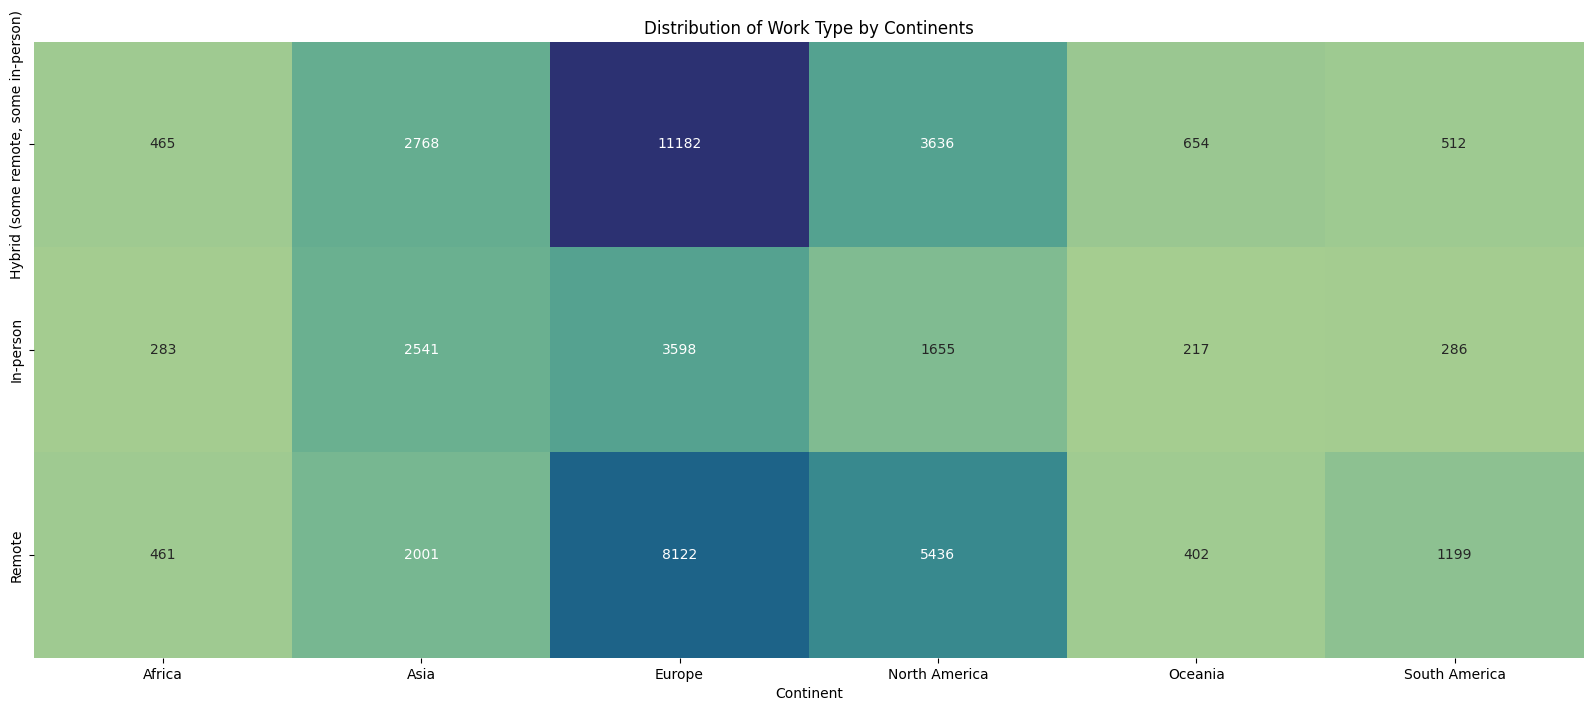

In [120]:
plt.figure(figsize=(20,8))
sns.heatmap(df_rem.T, cmap = 'crest', annot=True, fmt='.0f', cbar=False)
plt.title('Distribution of Work Type by Continents')

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.

- Анализируйте корреляцию между общей удовлетворенностью работой (JobSat) и количеством лет программирования (YearsCodePro).

- Рассчитайте коэффициент корреляции Пирсона или Спирмена.

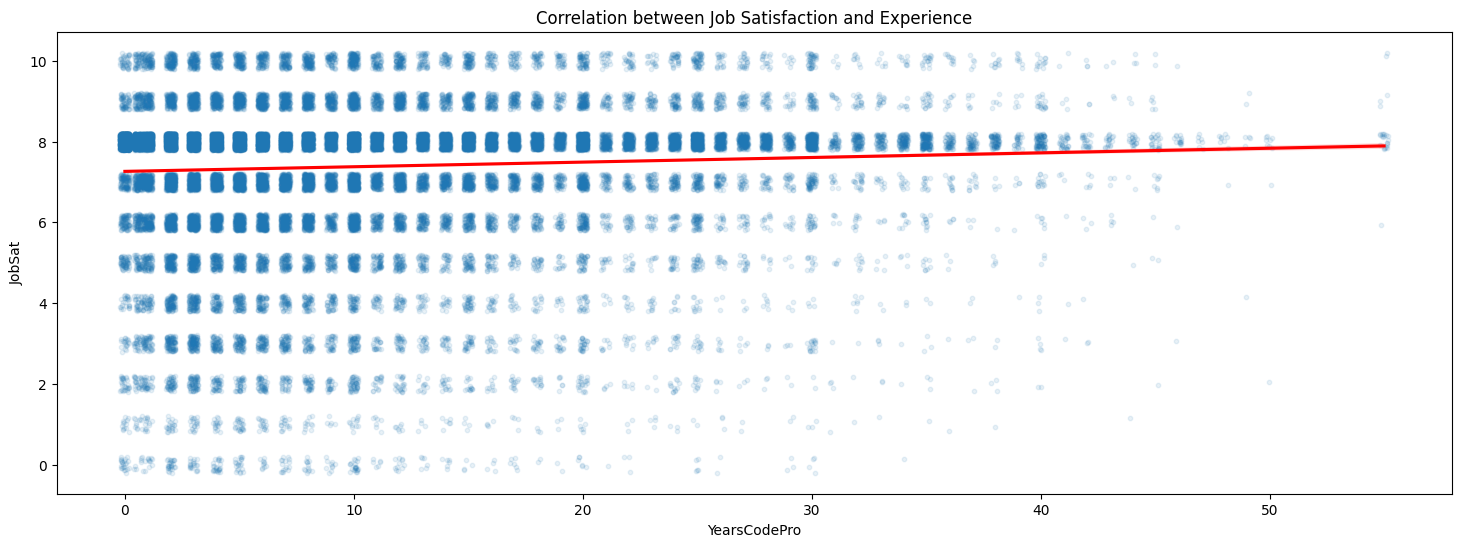

In [133]:
## Write your code here
plt.figure(figsize=(18,6))
sns.regplot(data=df,
            y='JobSat',
            x='YearsCodePro',
            scatter_kws={'alpha': 0.1, 's': 10},
            line_kws={'color': 'red'},
            x_jitter=0.2, y_jitter=0.2)
plt.title('Correlation between Job Satisfaction and Experience');

In [122]:
pearson, p_val = stats.spearmanr(df['JobSat'], df['YearsCodePro'])
print('Spearman Coefficient : ', pearson) # almost no corr
print('P-Value : ', p_val) #not truth corr

Spearman Coefficient :  0.048269842168151104
P-Value :  1.3968112200926277e-25


### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


In [123]:
## Write your code here
df_test = df[['Employment', 'EdLevel']]
edum = df_test['Employment'].str.get_dummies(sep=(';'))
df_fi = df_test.join(edum)

In [124]:
df_fi.drop(columns=['Employment'], inplace=True)

In [125]:
df_fi = df_fi.groupby(['EdLevel']).sum()
df_fi.head()

,"Employed, full-time","Employed, part-time","Independent contractor, freelancer, or self-employed","Not employed, and not looking for work","Not employed, but looking for work",Retired,"Student, full-time","Student, part-time"
EdLevel,,,,,,,,
"Associate degree (A.A., A.S., etc.)",1123,120,284,6,19,4,75,70
"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",17064,1192,3355,25,222,26,800,608
"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",11199,678,2410,18,100,18,276,278
Primary/elementary school,160,67,142,12,21,5,72,18
"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",2074,125,425,3,15,15,42,34


In [126]:
%matplotlib inline
plt.rcParams["figure.figsize"] = (16, 6)

<Figure size 2000x1000 with 0 Axes>

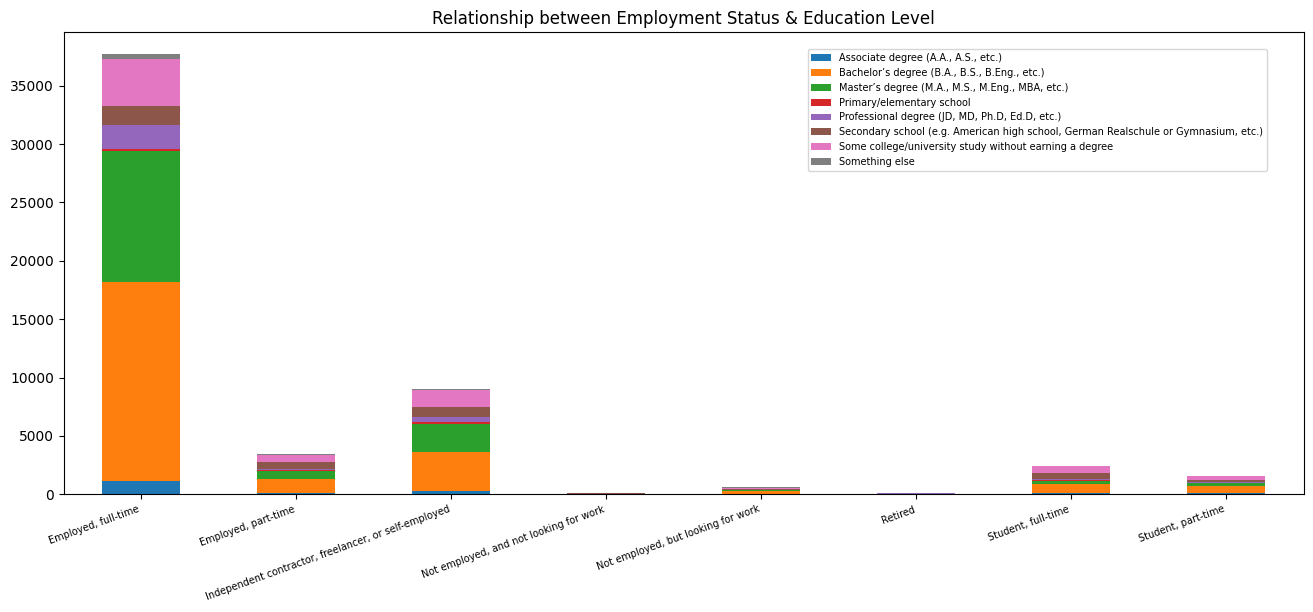

In [127]:
plt.figure(figsize=(20,10))
df_fi.T.plot(kind='bar', stacked=True)
plt.title('Relationship between Employment Status & Education Level')
plt.legend(loc=(0.6, 0.7), fontsize=7)
plt.xticks(rotation=20, ha='right', fontsize=7);

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [128]:
## Write your code here
df.to_csv('Lab11 Cleaned&Modified.csv')

### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
